# Data bilan tanishuv 

In [142]:
import pandas as pd 
df=pd.read_csv('job_salary_prediction_dataset.csv')

In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [144]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [83]:
df.drop(['job_title', 'location'], axis=1)

,experience_years,education_level,skills_count,industry,company_size,remote_work,certifications,salary
0,10,Bachelor,2,Healthcare,Medium,Hybrid,2,109413
1,5,Bachelor,17,Telecom,Small,No,0,93764
2,18,PhD,4,Media,Medium,No,1,148123
3,19,PhD,13,Retail,Medium,Yes,0,189123
4,15,Bachelor,7,Manufacturing,Large,Yes,0,165069
...,...,...,...,...,...,...,...,...
249995,17,PhD,2,Telecom,Enterprise,No,1,127791
249996,20,PhD,7,Telecom,Startup,No,2,154593
249997,1,Bachelor,12,Retail,Enterprise,Yes,0,75988
249998,0,High School,2,Consulting,Small,Hybrid,5,90467


# Data preprocessing 

# Encoding 

In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [85]:
from sklearn.preprocessing import LabelEncoder 
encoder=LabelEncoder()

In [86]:
def encodla(df):
    for col in df.columns:
        if df[col].dtype=='str':
            if df[col].nunique()<5:
                dummies=pd.get_dummies(df[col],prefix=col,dtype=int)
                df=pd.concat([df.drop(columns=[col]),dummies],axis=1)
            else:
                df[col]=encoder.fit_transform(df[col])
    return df   


In [87]:
df=encodla(df)

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   job_title           250000 non-null  int64
 1   experience_years    250000 non-null  int64
 2   education_level     250000 non-null  int64
 3   skills_count        250000 non-null  int64
 4   industry            250000 non-null  int64
 5   company_size        250000 non-null  int64
 6   location            250000 non-null  int64
 7   certifications      250000 non-null  int64
 8   salary              250000 non-null  int64
 9   remote_work_Hybrid  250000 non-null  int64
 10  remote_work_No      250000 non-null  int64
 11  remote_work_Yes     250000 non-null  int64
dtypes: int64(12)
memory usage: 22.9 MB


# Scaling 

In [89]:
from sklearn.preprocessing import MinMaxScaler

In [90]:
def scaling_qil(df):
    scaler=MinMaxScaler()
    num_col = df.select_dtypes(include=['int64','float64']).columns
    df[num_col]=scaler.fit_transform(df[num_col]) 
    return df

In [91]:
df=scaling_qil(df)

In [92]:
df.sample(8)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,certifications,salary,remote_work_Hybrid,remote_work_No,remote_work_Yes
27226,0.545455,0.65,0.50,0.055556,0.222222,0.50,1.000000,0.2,0.429416,0.0,1.0,0.0
192254,0.545455,0.85,0.75,0.833333,0.444444,0.50,0.111111,0.0,0.559601,0.0,0.0,1.0
129504,0.909091,0.55,0.25,0.444444,0.555556,1.00,0.444444,0.2,0.265443,0.0,0.0,1.0
86720,0.727273,0.10,1.00,0.444444,0.000000,1.00,0.333333,0.6,0.171240,0.0,1.0,0.0
214810,0.727273,0.65,0.25,0.222222,0.666667,1.00,0.666667,0.8,0.280262,0.0,1.0,0.0
56810,0.545455,0.00,0.25,0.888889,0.111111,0.50,0.333333,0.4,0.171569,1.0,0.0,0.0
13966,0.545455,0.45,0.75,0.277778,0.444444,0.75,0.888889,0.4,0.376431,1.0,0.0,0.0
100993,0.818182,0.65,0.25,0.111111,1.000000,0.00,0.000000,0.4,0.454557,1.0,0.0,0.0


# Train,Test split

In [93]:
X=df.drop('salary',axis=1)

In [94]:
y=df['salary']

In [95]:
y

0         0.257475
1         0.205516
2         0.386003
3         0.522135
4         0.442269
            ...   
249995    0.318495
249996    0.407485
249997    0.146494
249998    0.194569
249999    0.336069
Name: salary, Length: 250000, dtype: float64

In [96]:
from sklearn.model_selection import train_test_split

In [97]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Model Selection

In [98]:
from sklearn.linear_model import LinearRegression 

In [99]:
lr=LinearRegression()

In [100]:
lr.fit(X_train, y_train) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Prediction

In [101]:
y_pred=lr.predict(X_test)
y_pred

array([0.23581855, 0.3219477 , 0.25920915, ..., 0.4761369 , 0.43301276,
       0.20906463], shape=(50000,))

# Evaluatin 

In [102]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [115]:
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)

In [116]:
print(r2)
print(mse)
print(mae)

0.9308426449670056
0.0010596469507558692
0.02524736744593747


# Decision Tree

In [105]:
from sklearn.tree import DecisionTreeRegressor

In [106]:
dr=DecisionTreeRegressor()

In [107]:
dr

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [108]:
dr.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

# Pridict

In [109]:
y_pred=dr.predict(X_test)

In [110]:
y_pred

array([0.44517048, 0.23267891, 0.15594713, ..., 0.39450958, 0.39010024,
       0.28788196], shape=(50000,))

In [111]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [112]:
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)


In [113]:
print('r2:',r2)
print('mae:',mae)
print('mse:',mse)

r2: 0.9308426449670056
mae: 0.02524736744593747
mse: 0.0010596469507558692


# Random Forest

In [118]:
from sklearn.ensemble import  RandomForestRegressor

In [119]:
rd=RandomForestRegressor()

In [120]:
rd.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [121]:
y_pred=rd.predict(X_test)

In [122]:
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

In [123]:
print('r2:',r2)
print('mae:',mae)
print('mse:',mse)

r2: 0.9689748662581156
mae: 0.017244679659824985
mse: 0.0004753751549736989


In [124]:
from tabulate import tabulate

result = [
    ['Logistic Regression',0.930,0.025,0.001],
    ['Decision Tree', 0.930,0.025,0.001],
    ['Random Forest',0.968,0.017,0.000],
]

headers = ['Algorithm', 'R2_score', 'MAE', 'MSE']

table = tabulate(result, headers=headers, tablefmt='grid')

print(table)

+---------------------+------------+-------+-------+
| Algorithm           |   R2_score |   MAE |   MSE |
+=====================+============+=======+=======+
| Logistic Regression |      0.93  | 0.025 | 0.001 |
+---------------------+------------+-------+-------+
| Decision Tree       |      0.93  | 0.025 | 0.001 |
+---------------------+------------+-------+-------+
| Random Forest       |      0.968 | 0.017 | 0     |
+---------------------+------------+-------+-------+


# visualization

In [125]:
import matplotlib.pyplot as plt

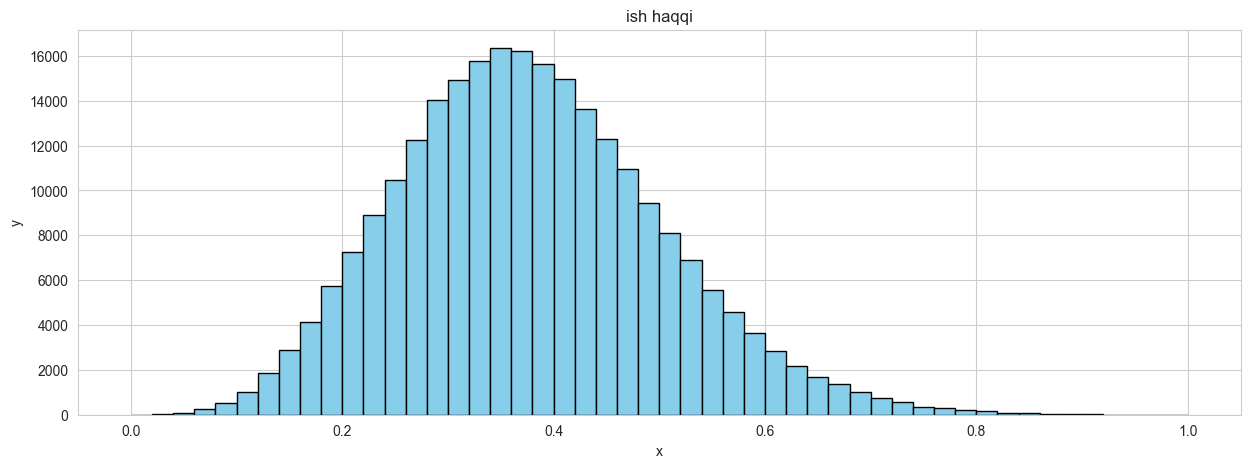

In [128]:
plt.figure(figsize=(15,5))
plt.hist(df['salary'],bins=50, color='skyblue',edgecolor='black')
plt.title('ish haqqi')
plt.xlabel('x')
plt.ylabel('y')
 
plt.show()

In [129]:
import seaborn as sns

In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   job_title           250000 non-null  float64
 1   experience_years    250000 non-null  float64
 2   education_level     250000 non-null  float64
 3   skills_count        250000 non-null  float64
 4   industry            250000 non-null  float64
 5   company_size        250000 non-null  float64
 6   location            250000 non-null  float64
 7   certifications      250000 non-null  float64
 8   salary              250000 non-null  float64
 9   remote_work_Hybrid  250000 non-null  float64
 10  remote_work_No      250000 non-null  float64
 11  remote_work_Yes     250000 non-null  float64
dtypes: float64(12)
memory usage: 22.9 MB


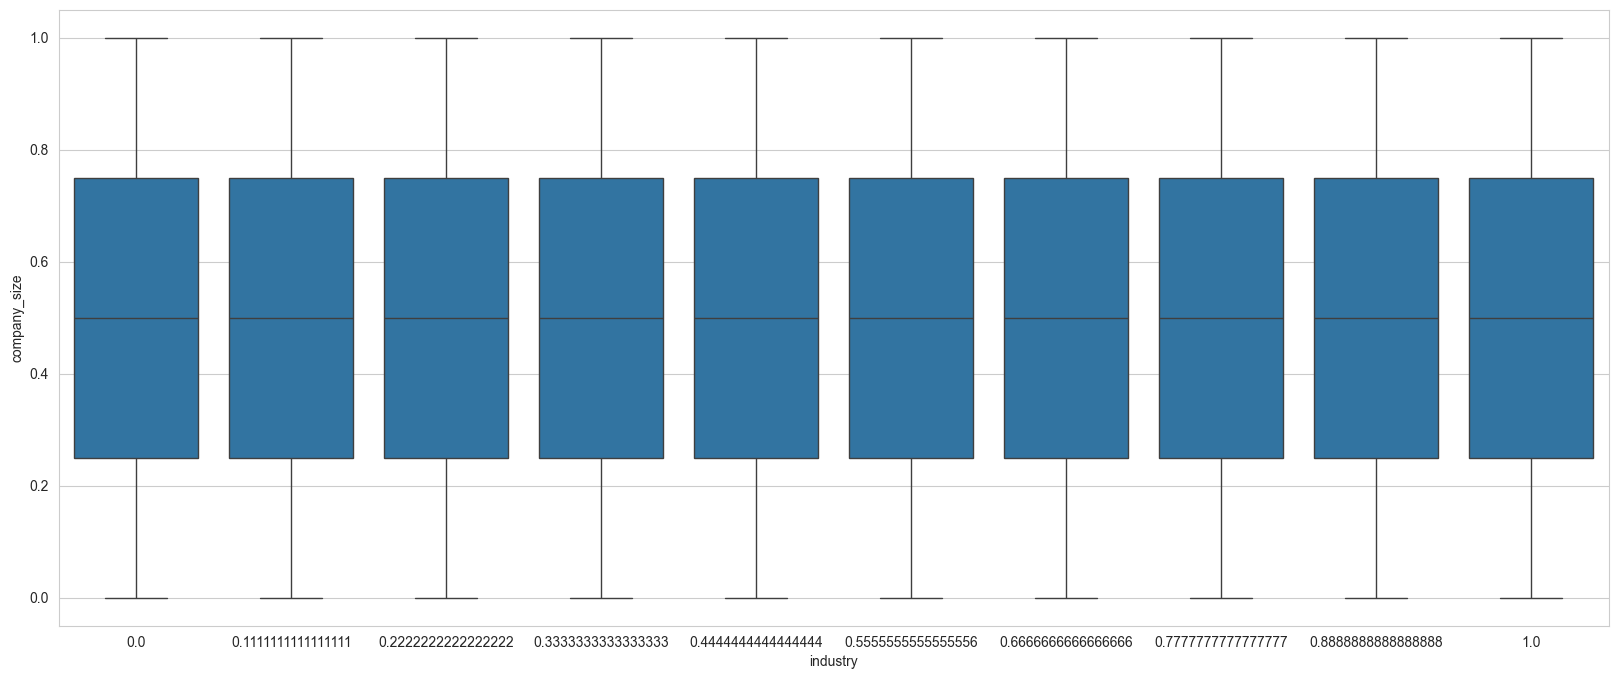

In [133]:
plt.figure(figsize=(20,8))
sns.boxplot(x='industry', y='company_size',data=df)

plt.show()

In [134]:
import plotly.express as px

In [145]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [149]:
import plotly.io as pio

pio.renderers.default = "browser"

In [151]:
fig=px.scatter(df,x='job_title',y='education_level',color='industry',hover_data=['company_size','location'],title='ish haqqini oshishi')
fig.show()